# Demonstrating Data Segmentation (Sliding Window)

**Goal:** Visualize the Data Segmentation process and confirm the Data Augmentation effect.

**Methodology:**
1.  **Filter**: Apply 40 Hz Low-Pass Filter (preprocessing).
2.  **Segment**: Apply Overlapping Sliding Window (Window=178, Step=45, Overlap=75%).
3.  **Result**: 500 signals $\rightarrow$ ~44,000 segments.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('..'))
from src.data_processing.loader import load_bonn_data
from src.data_processing.filtering import apply_lowpass_filter
from src.data_processing.segmentation import segment_data

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Filter Data

In [2]:
# Load data
data_path = os.path.join(os.path.abspath('..'), 'data', 'raw')
X, y = load_bonn_data(data_path)

# Apply Filter (Standard Preprocessing Step)
X_filtered = apply_lowpass_filter(X, cutoff=40.0)

print(f"Original Data Shape: {X_filtered.shape}")

Loading 100 files from Z (Class 0)...
Loading 100 files from O (Class 0)...
Loading 100 files from N (Class 0)...
Loading 100 files from F (Class 0)...
Loading 100 files from S (Class 1)...
Original Data Shape: (500, 4097)


## 2. Apply Segmentation
We use a window of 1 second (178 points) and a step of ~0.25 seconds (45 points), resulting in 75% overlap.

In [3]:
WINDOW_SIZE = 178
STEP_SIZE = 45

X_seg, y_seg = segment_data(X_filtered, y, window_size=WINDOW_SIZE, step_size=STEP_SIZE)

print(f"Segmented Data Shape: {X_seg.shape}")
print(f"Segmented Labels Shape: {y_seg.shape}")
print(f"Expansion Factor: {X_seg.shape[0] / X.shape[0]:.1f}x")

Segmented Data Shape: (44000, 178)
Segmented Labels Shape: (44000,)
Expansion Factor: 88.0x


## 3. Visualization
Let's visualize how a single signal is broken down into overlapping segments.

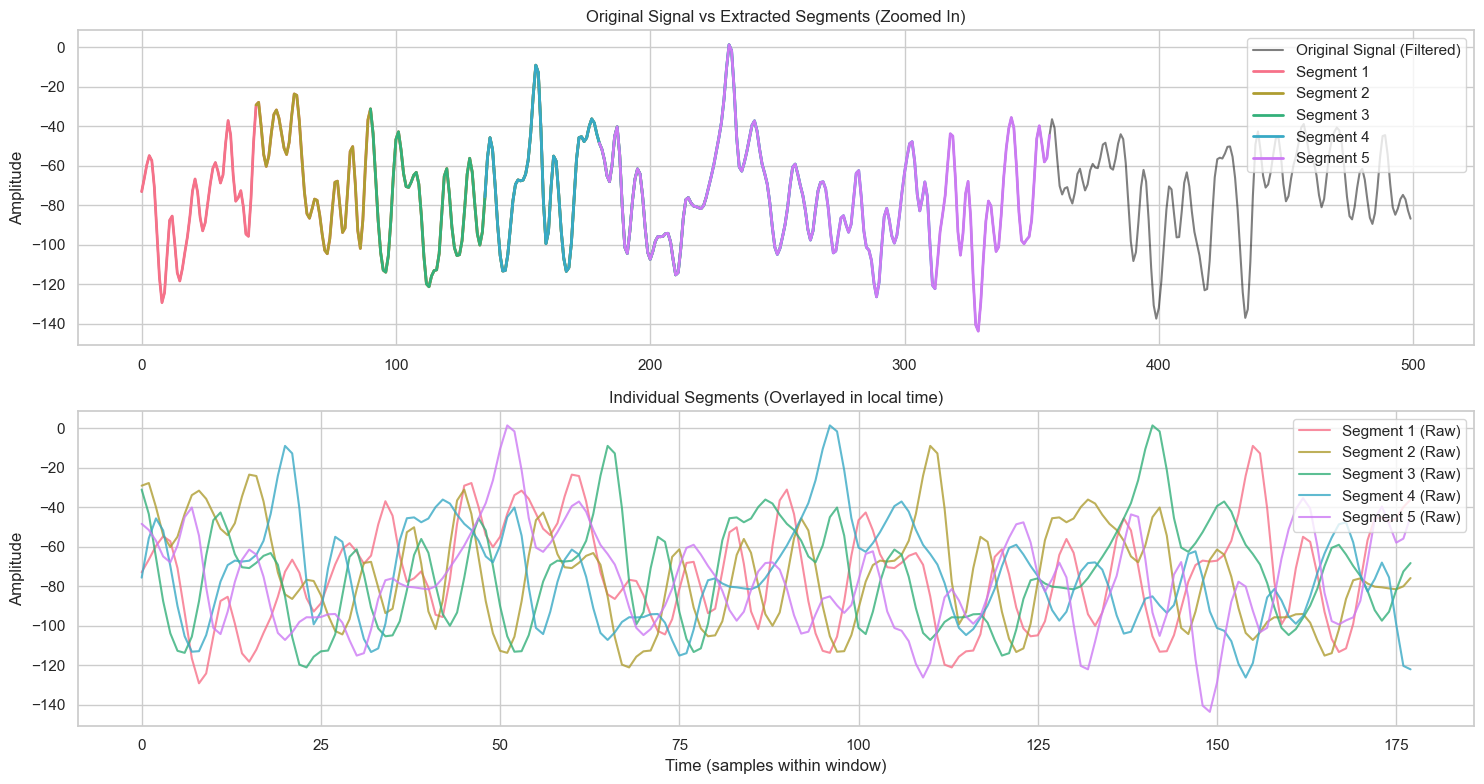

In [4]:
# Select one random signal (e.g., Signal 0)
signal_idx = 0
original_signal = X_filtered[signal_idx]

# Get the segments corresponding to this signal
# Since we know the number of segments per signal is constant:
segments_per_signal = X_seg.shape[0] // X.shape[0]
start_seg_idx = signal_idx * segments_per_signal
end_seg_idx = start_seg_idx + 5 # Let's show first 5 segments

selected_segments = X_seg[start_seg_idx:end_seg_idx]

plt.figure(figsize=(15, 8))

# Plot Original Signal (First 500 points for clarity)
plt.subplot(2, 1, 1)
plt.plot(original_signal[:500], label='Original Signal (Filtered)', color='black', alpha=0.5)
plt.title('Original Signal vs Extracted Segments (Zoomed In)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')

# Plot Segments identifying their position
colors = sns.color_palette("husl", len(selected_segments))
for i, segment in enumerate(selected_segments):
    # Calculate where this segment sits in time
    start_time = i * STEP_SIZE
    time_axis = np.arange(start_time, start_time + WINDOW_SIZE)
    
    # Plot on top of original
    plt.plot(time_axis, segment, label=f'Segment {i+1}', color=colors[i], linewidth=2)

plt.legend(loc='upper right')

# Plot individual segments separately
plt.subplot(2, 1, 2)
for i, segment in enumerate(selected_segments):
    plt.plot(segment, label=f'Segment {i+1} (Raw)', color=colors[i], alpha=0.8)

plt.title('Individual Segments (Overlayed in local time)')
plt.xlabel('Time (samples within window)')
plt.ylabel('Amplitude')
plt.legend()

plt.tight_layout()
plt.show()